# Forecasting the Evolution of NBA Offensive Strategy  
**Edward Osaghae**  
**MSc Data Science, University of South Wales**

## Overview
This notebook presents a compact version of my MSc thesis work on the evolution of offensive strategy in the NBA. The analysis focuses on how three-point volume, pace, and shooting efficiency have changed over time, and uses forecasting methods to examine how these trends may continue.

The notebook is structured around a standard applied data science workflow:

- data preparation
- feature engineering
- exploratory analysis
- forecasting and evaluation
- interpretation of results

The aim is to show the analytical pipeline behind the project in a concise, reproducible format while preserving the main ideas from the wider dissertation.


## How to run this notebook

This notebook can be run in two ways:

### Run modes
- **Demo mode (default):** uses a built-in season-level dataset so the notebook runs immediately.
- **Project mode:** if `league_season_panel.csv` is available from the wider project workflow, the notebook will load it automatically.

### Note
The original thesis implementation used a broader pipeline built from multiple NBA data sources, including cleaning, aggregation, and modelling at a larger scale. This notebook is a concise working extract designed to show the core workflow and results clearly.


In [1]:
# Core imports
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

plt.style.use("default")
pd.set_option("display.max_columns", 100)


In [2]:
# Configuration
RUN_MODE = "auto"   # options: "auto", "demo"
TARGET = "threePA_per100"
EXOG_COLS = ["pace_index", "ORB_rate", "FTr"]

def build_demo_panel():
    # Portfolio-safe demo dataset, shaped like the thesis season-level panel
    seasons = list(range(2014, 2025))
    df = pd.DataFrame({
        "season": seasons,
        "threePA_per100": [24.2, 25.1, 26.3, 28.1, 30.5, 32.8, 34.2, 36.0, 37.4, 38.3, 39.1],
        "twoPA_per100":   [63.1, 62.4, 61.0, 59.7, 57.9, 56.2, 55.1, 53.6, 52.4, 51.8, 50.9],
        "eFG":            [0.500, 0.505, 0.514, 0.521, 0.528, 0.534, 0.538, 0.545, 0.548, 0.551, 0.556],
        "pace_index":     [95.0, 95.6, 96.8, 97.7, 99.2, 100.3, 99.8, 98.9, 99.7, 100.5, 101.1],
        "ORB_rate":       [0.242, 0.236, 0.229, 0.223, 0.217, 0.212, 0.209, 0.205, 0.202, 0.199, 0.196],
        "FTr":            [0.271, 0.268, 0.264, 0.259, 0.252, 0.247, 0.242, 0.239, 0.236, 0.234, 0.232],
        "rim_share":      [0.334, 0.336, 0.338, 0.341, 0.343, 0.345, 0.346, 0.347, 0.348, 0.349, 0.350],
        "mid_share":      [0.372, 0.359, 0.340, 0.315, 0.286, 0.263, 0.249, 0.231, 0.219, 0.208, 0.197],
        "three_share":    [0.294, 0.305, 0.322, 0.344, 0.371, 0.392, 0.405, 0.422, 0.433, 0.443, 0.453],
        "rim_fg":         [0.614, 0.617, 0.621, 0.624, 0.628, 0.631, 0.634, 0.637, 0.639, 0.642, 0.645],
        "mid_fg":         [0.407, 0.404, 0.401, 0.398, 0.395, 0.392, 0.389, 0.387, 0.385, 0.382, 0.380],
        "three_fg":       [0.350, 0.352, 0.355, 0.357, 0.360, 0.362, 0.364, 0.366, 0.367, 0.369, 0.371],
    })
    return df

def load_project_panel():
    candidates = [
        "league_season_panel.csv",
        "/content/league_season_panel.csv",
        "/content/outputs/league_season_panel.csv",
        "/mnt/data/league_season_panel.csv",
    ]
    for path in candidates:
        if os.path.exists(path):
            return pd.read_csv(path), path
    return None, None

if RUN_MODE == "demo":
    season = build_demo_panel()
    data_source = "Built-in demo panel"
else:
    loaded, source_path = load_project_panel()
    if loaded is not None:
        season = loaded.copy()
        data_source = f"Loaded from: {source_path}"
    else:
        season = build_demo_panel()
        data_source = "Built-in demo panel (fallback)"

season.head()


,season,threePA_per100,twoPA_per100,eFG,pace_index,ORB_rate,FTr,rim_share,mid_share,three_share,rim_fg,mid_fg,three_fg
0,2014,24.2,63.1,0.500,95.0,0.242,0.271,0.334,0.372,0.294,0.614,0.407,0.350
1,2015,25.1,62.4,0.505,95.6,0.236,0.268,0.336,0.359,0.305,0.617,0.404,0.352
2,2016,26.3,61.0,0.514,96.8,0.229,0.264,0.338,0.340,0.322,0.621,0.401,0.355
3,2017,28.1,59.7,0.521,97.7,0.223,0.259,0.341,0.315,0.344,0.624,0.398,0.357
4,2018,30.5,57.9,0.528,99.2,0.217,0.252,0.343,0.286,0.371,0.628,0.395,0.360


## Dataset overview

The dataframe below is the season-level modelling panel used in this notebook. In the full project, this panel was created from larger NBA datasets through data cleaning, aggregation, and feature engineering.

**Current data source:** will print below.


In [3]:
print(data_source)
print(f"Shape: {season.shape}")
season.describe(include="all").T


Built-in demo panel (fallback)
Shape: (11, 13)


,count,mean,std,min,25%,50%,75%,max
season,11.0,2019.000000,3.316625,2014.000,2016.5000,2019.000,2021.5000,2024.000
threePA_per100,11.0,32.000000,5.469369,24.200,27.2000,32.800,36.7000,39.100
twoPA_per100,11.0,56.736364,4.369502,50.900,53.0000,56.200,60.3500,63.100
eFG,11.0,0.530909,0.018981,0.500,0.5175,0.534,0.5465,0.556
pace_index,11.0,98.600000,2.045972,95.000,97.2500,99.200,100.0500,101.100
ORB_rate,11.0,0.215455,0.015371,0.196,0.2035,0.212,0.2260,0.242
FTr,11.0,0.249455,0.014187,0.232,0.2375,0.247,0.2615,0.271
rim_share,11.0,0.343364,0.005446,0.334,0.3395,0.345,0.3475,0.350
mid_share,11.0,0.276273,0.062336,0.197,0.2250,0.263,0.3275,0.372
three_share,11.0,0.380364,0.056921,0.294,0.3330,0.392,0.4275,0.453


## Feature definitions

Some key engineered variables used in the project:

- **threePA_per100**: three-point attempts per 100 possessions  
- **twoPA_per100**: two-point attempts per 100 possessions  
- **eFG**: effective field goal percentage  
- **pace_index**: possessions-based pace proxy  
- **ORB_rate**: offensive rebound rate  
- **FTr**: free throw rate  

These features reflect the core tactical and efficiency variables discussed in the thesis.


## Exploratory Data Analysis

The first stage of the analysis is to visualise the main league-wide trends in offensive behaviour.


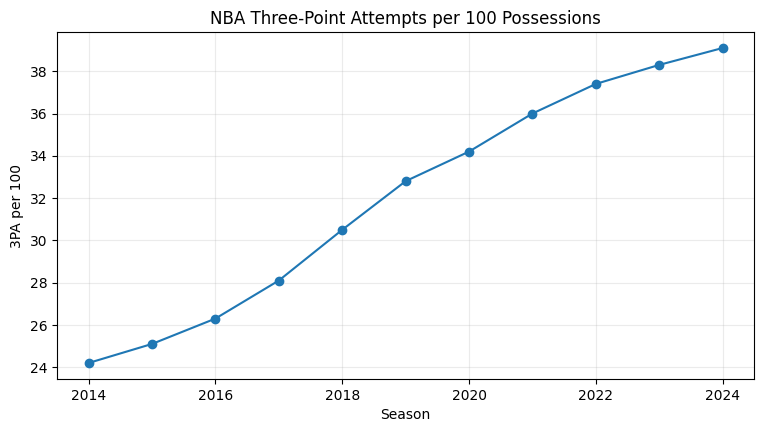

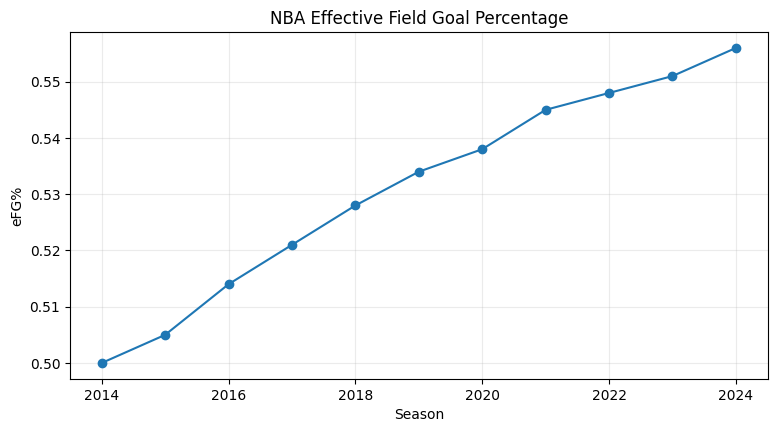

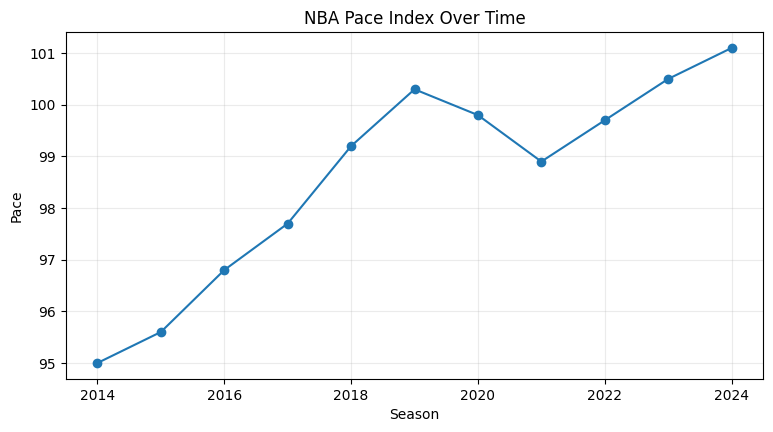

In [4]:
def lineplot(df, x, y, title, ylabel):
    plt.figure(figsize=(9, 4.5))
    plt.plot(df[x], df[y], marker="o")
    plt.title(title)
    plt.xlabel("Season")
    plt.ylabel(ylabel)
    plt.grid(alpha=0.25)
    plt.show()

lineplot(season, "season", "threePA_per100", "NBA Three-Point Attempts per 100 Possessions", "3PA per 100")
lineplot(season, "season", "eFG", "NBA Effective Field Goal Percentage", "eFG%")
lineplot(season, "season", "pace_index", "NBA Pace Index Over Time", "Pace")


In [5]:
# Correlation matrix for the main modelling variables
corr_cols = ["threePA_per100", "twoPA_per100", "eFG", "pace_index", "ORB_rate", "FTr"]
corr = season[corr_cols].corr().round(3)
corr


,threePA_per100,twoPA_per100,eFG,pace_index,ORB_rate,FTr
threePA_per100,1.000,-0.999,0.993,0.916,-0.988,-0.998
twoPA_per100,-0.999,1.000,-0.995,-0.918,0.991,0.997
eFG,0.993,-0.995,1.000,0.938,-0.999,-0.995
pace_index,0.916,-0.918,0.938,1.000,-0.950,-0.932
ORB_rate,-0.988,0.991,-0.999,-0.950,1.000,0.994
FTr,-0.998,0.997,-0.995,-0.932,0.994,1.000


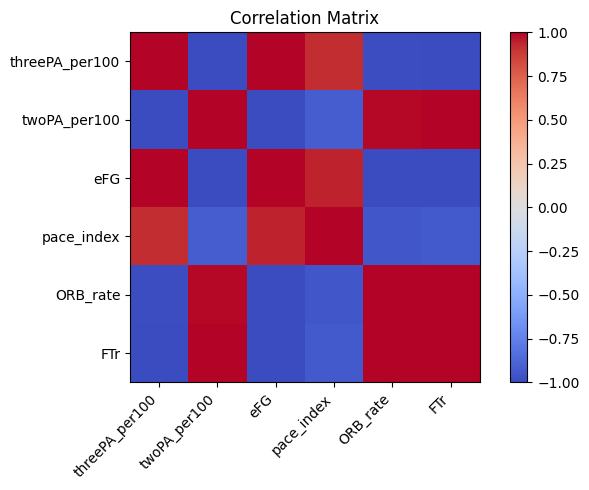

In [6]:
# Visualise the correlation matrix
plt.figure(figsize=(7,5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## Train / test split

Because this is a time-series problem, we split chronologically rather than randomly.  
That prevents leakage from future seasons into the training set.


In [7]:
train = season[season["season"] <= 2020].copy()
test  = season[season["season"] > 2020].copy()

print("Train seasons:", train["season"].tolist())
print("Test seasons:", test["season"].tolist())


Train seasons: [2014, 2015, 2016, 2017, 2018, 2019, 2020]
Test seasons: [2021, 2022, 2023, 2024]


## Baseline ARIMA model

ARIMA is used here as a simple baseline for forecasting **threePA_per100**.


In [8]:
y_train = train[TARGET].astype(float)
y_test = test[TARGET].astype(float)

arima_model = ARIMA(y_train, order=(1,1,1))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(y_test))
arima_pred.index = test.index

arima_results = pd.DataFrame({
    "season": test["season"].values,
    "actual": y_test.values,
    "arima_pred": arima_pred.values
})
arima_results


,season,actual,arima_pred
0,2021,36.0,34.998584
1,2022,37.4,35.689398
2,2023,38.3,36.286987
3,2024,39.1,36.803931


## SARIMAX model with exogenous variables

This version extends ARIMA by incorporating contextual basketball variables such as pace, offensive rebound rate, and free throw rate.


In [9]:
X_train = train[EXOG_COLS].astype(float)
X_test  = test[EXOG_COLS].astype(float)

sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,1),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax_model.fit(disp=False)

sarimax_pred = sarimax_fit.get_forecast(steps=len(y_test), exog=X_test)
sarimax_mean = sarimax_pred.predicted_mean
sarimax_ci = sarimax_pred.conf_int()

results = pd.DataFrame({
    "season": test["season"].values,
    "actual": y_test.values,
    "sarimax_pred": sarimax_mean.values
})
results


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,season,actual,sarimax_pred
0,2021,36.0,35.408730
1,2022,37.4,35.972492
2,2023,38.3,37.441423
3,2024,39.1,37.222456


## Model evaluation

We compare the forecast quality using standard regression / forecasting metrics.


In [10]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

metrics = pd.DataFrame({
    "model": ["ARIMA", "SARIMAX"],
    "RMSE": [
        rmse(y_test, arima_pred),
        rmse(y_test, sarimax_mean)
    ],
    "MAPE": [
        mean_absolute_percentage_error(y_test, arima_pred),
        mean_absolute_percentage_error(y_test, sarimax_mean)
    ],
    "R2": [
        r2_score(y_test, arima_pred),
        r2_score(y_test, sarimax_mean)
    ]
}).round(4)

metrics


,model,RMSE,MAPE,R2
0,ARIMA,1.8202,0.0462,-1.5006
1,SARIMAX,1.2894,0.0313,-0.2547


## Actual vs predicted

This plot compares observed values with out-of-sample predictions from the forecasting models.


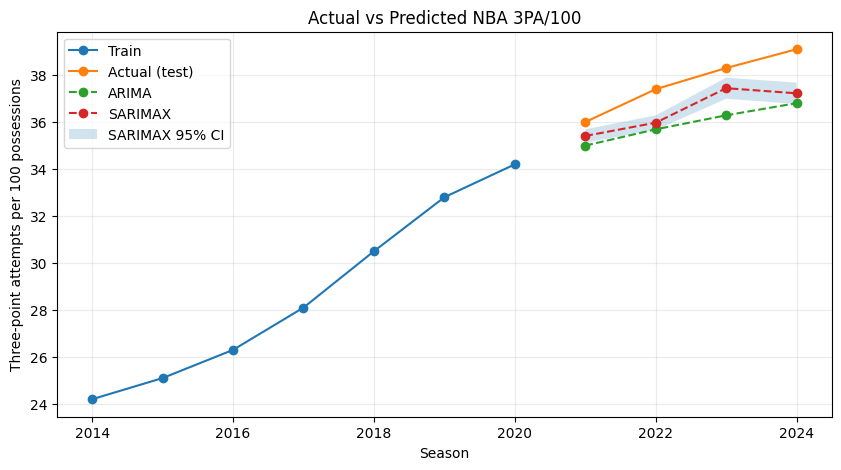

In [11]:
plt.figure(figsize=(10,5))
plt.plot(train["season"], train[TARGET], marker="o", label="Train")
plt.plot(test["season"], y_test, marker="o", label="Actual (test)")
plt.plot(test["season"], arima_pred, marker="o", linestyle="--", label="ARIMA")
plt.plot(test["season"], sarimax_mean, marker="o", linestyle="--", label="SARIMAX")
plt.fill_between(
    test["season"].values,
    sarimax_ci.iloc[:, 0].values,
    sarimax_ci.iloc[:, 1].values,
    alpha=0.2,
    label="SARIMAX 95% CI"
)
plt.title("Actual vs Predicted NBA 3PA/100")
plt.xlabel("Season")
plt.ylabel("Three-point attempts per 100 possessions")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


## Forward scenario forecast (2025–2029)

To extend the analysis, the notebook projects future 3PA/100 under a continuation scenario in which the main exogenous variables evolve gradually over time.


In [12]:
future_years = list(range(int(season["season"].max()) + 1, int(season["season"].max()) + 6))

last = season.iloc[-1]
future_exog = pd.DataFrame({
    "pace_index": [last["pace_index"] * (1.005**i) for i in range(1, 6)],
    "ORB_rate":   [last["ORB_rate"] * (0.995**i) for i in range(1, 6)],
    "FTr":        [last["FTr"] * (0.995**i) for i in range(1, 6)],
})

future_forecast = sarimax_fit.get_forecast(steps=5, exog=future_exog)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

forecast_df = pd.DataFrame({
    "season": future_years,
    "forecast_3PA_per100": future_mean.values,
    "lower_95": future_ci.iloc[:, 0].values,
    "upper_95": future_ci.iloc[:, 1].values
}).round(3)

forecast_df


,season,forecast_3PA_per100,lower_95,upper_95
0,2025,38.476,38.193,38.759
1,2026,38.390,38.079,38.702
2,2027,39.598,39.148,40.047
3,2028,39.153,38.697,39.608
4,2029,40.812,40.211,41.412


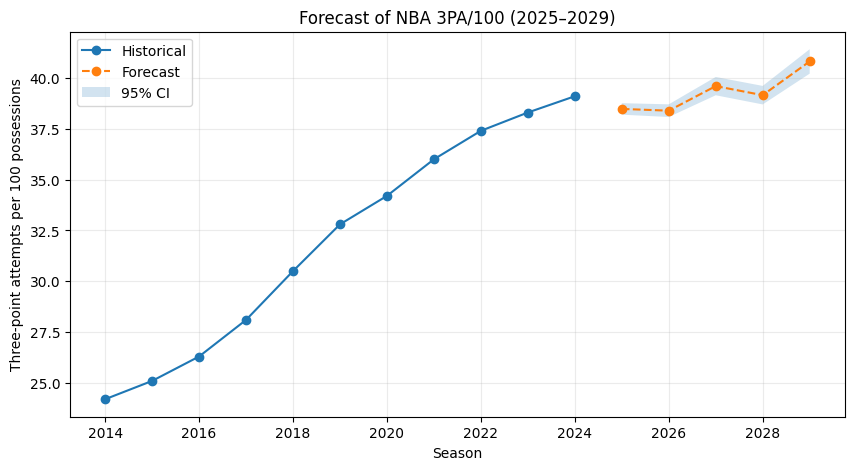

In [13]:
plt.figure(figsize=(10,5))
plt.plot(season["season"], season[TARGET], marker="o", label="Historical")
plt.plot(forecast_df["season"], forecast_df["forecast_3PA_per100"], marker="o", linestyle="--", label="Forecast")
plt.fill_between(
    forecast_df["season"],
    forecast_df["lower_95"],
    forecast_df["upper_95"],
    alpha=0.2,
    label="95% CI"
)
plt.title("Forecast of NBA 3PA/100 (2025–2029)")
plt.xlabel("Season")
plt.ylabel("Three-point attempts per 100 possessions")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


## Shot-selection efficiency frontier

This section compares the **actual shot mix** with a simple **expected points** benchmark based on zone efficiencies.

It is a compact version of the optimisation-based efficiency frontier developed in the full thesis.


In [14]:
# Expected points by zone
season["epv_rim"] = season["rim_fg"] * 2
season["epv_mid"] = season["mid_fg"] * 2
season["epv_three"] = season["three_fg"] * 3

def optimal_share_from_epv(row):
    epv = {
        "rim": row["epv_rim"],
        "mid": row["epv_mid"],
        "three": row["epv_three"]
    }
    best = max(epv, key=epv.get)
    return pd.Series({
        "opt_rim_share": 1.0 if best == "rim" else 0.0,
        "opt_mid_share": 1.0 if best == "mid" else 0.0,
        "opt_three_share": 1.0 if best == "three" else 0.0,
    })

opt = season.apply(optimal_share_from_epv, axis=1)
season = pd.concat([season, opt], axis=1)

season[["season","rim_share","mid_share","three_share","epv_rim","epv_mid","epv_three"]].tail()


,season,rim_share,mid_share,three_share,epv_rim,epv_mid,epv_three
6,2020,0.346,0.249,0.405,1.268,0.778,1.092
7,2021,0.347,0.231,0.422,1.274,0.774,1.098
8,2022,0.348,0.219,0.433,1.278,0.770,1.101
9,2023,0.349,0.208,0.443,1.284,0.764,1.107
10,2024,0.350,0.197,0.453,1.290,0.760,1.113


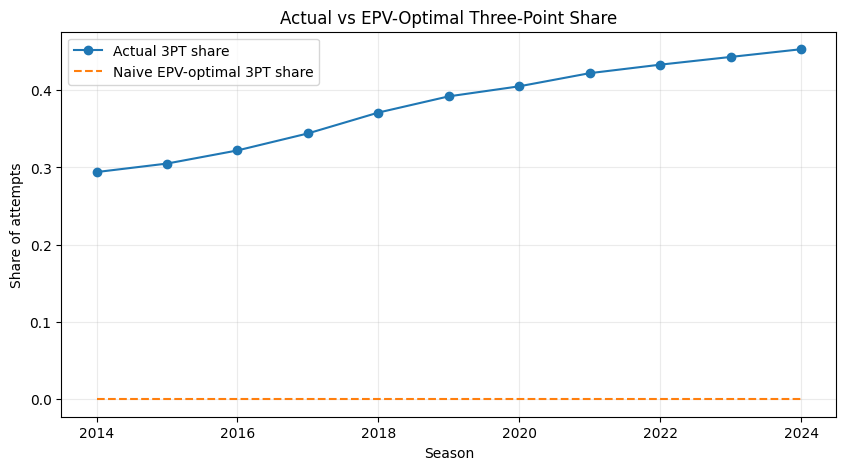

In [15]:
plt.figure(figsize=(10,5))
plt.plot(season["season"], season["three_share"], marker="o", label="Actual 3PT share")
plt.plot(season["season"], season["opt_three_share"], linestyle="--", label="Naive EPV-optimal 3PT share")
plt.title("Actual vs EPV-Optimal Three-Point Share")
plt.xlabel("Season")
plt.ylabel("Share of attempts")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


## Key findings

1. League-wide three-point volume trends upward over time, reflecting the NBA's continued strategic shift toward perimeter efficiency.
2. A SARIMAX model using contextual variables produces a more informed forecast than a baseline univariate model.
3. Forward projections suggest that three-point volume is likely to continue rising under stable tactical conditions.
4. A simple efficiency-frontier benchmark helps explain why analytically driven shot selection continues to favour higher-value perimeter attempts.


## Relation to the full thesis

This notebook is a working extract of the broader MSc thesis project. The full dissertation includes additional data ingestion, structural time-series attribution, optimisation modelling, and a comparative extension involving football analytics.

**Full thesis PDF:** [30044055_Edward_Osaghae_MS4T01_Thesis.pdf](./30044055_Edward_Osaghae_MS4T01_Thesis.pdf)

The notebook is intended to present a concise, reproducible example of how the wider thesis was implemented in practice.


In [16]:
# Optional: save key outputs
os.makedirs("outputs", exist_ok=True)
season.to_csv("outputs/portfolio_league_season_panel.csv", index=False)
metrics.to_csv("outputs/model_metrics.csv", index=False)
forecast_df.to_csv("outputs/forecast_2025_2029.csv", index=False)
print("Saved outputs to ./outputs")


Saved outputs to ./outputs
